**Some Data Cleaning**

In [128]:
import pandas as pd
import numpy as np

def build_sector_panel(sector_name, tickers, base_path="Stock Data"):

    price_path  = f"{base_path}/{sector_name}_Stocks_prices 2014_2024.csv"
    return_path = f"{base_path}/{sector_name}_Stocks_Returns 2014_2024.csv"

    df_price  = pd.read_csv(price_path)
    df_return = pd.read_csv(return_path)

    df = pd.merge(df_price, df_return, how="left", on="Date")

    all_rows = []

    for t in tickers:

        cols = ['Date'] + [col for col in df.columns if col.startswith(t + "_")]

        tmp = df[cols].copy()

        tmp.insert(1, "ticker", t)
        tmp.insert(2, "sector", sector_name)

        tmp = tmp.rename(columns=lambda c: c.replace(t + "_", "")
                         if c not in ["Date","ticker","sector"] else c)

        all_rows.append(tmp)

    # 4. Stack all tickers vertically
    final_df = pd.concat(all_rows, ignore_index=True)

    return final_df


In [129]:
Tech_list = ['AAPL', 'MSFT', 'NVDA', 'CRM', 'ORCL','AVGO','INTC','AMD','CSCO','MU']
Tech_df = build_sector_panel('Tech', Tech_list)

Finance_list = ['BRK-B', 'JPM', 'V','BAC','MA', 'WFC','C', 'GS', 'MS','AXP']
Finance_df = build_sector_panel('Financial', Finance_list)

CC_list = ['AMZN', 'TSLA', 'HD', 'MCD', 'TJX','BKNG','LOW','MELI','SBUX','NKE']
CC_df = build_sector_panel('Consumer_Cyclical', CC_list)

Com_list = ['GOOG', 'META', 'NFLX', 'TMUS', 'CMCSA','ZG','T','DIS','VZ','YELP']
Com_df = build_sector_panel('Communication', Com_list)

Util_list = ['DUK', 'NEE', 'SO', 'AEP', 'XEL','PEG','SRE','WEC','D','ETR']
Util_df = build_sector_panel('Utilities', Util_list)

Heal_list = ['LLY', 'JNJ', 'ABBV', 'UNH', 'MRK','ABT','TMO','ISRG','AMGN','DHR']
Heal_df = build_sector_panel('Health_Care', Heal_list)


In [130]:
df = pd.concat(
    [Tech_df, Finance_df, CC_df, Com_df, Util_df, Heal_df],
    ignore_index=True
)
df["sector"] = df["sector"].replace("Health_Care", "Healthcare")
df["sector"] = df["sector"].replace("Utilities", "Utility")
df["sector"] = df["sector"].replace("Consumer_Cyclical", "Consumer Cyclical")
df["sector"] = df["sector"].replace("Financial", "Finance")
df["sector"] = df["sector"].replace("Tech", "Technology")
df["sector"] = df["sector"].replace("Communication", "Communication Services")
#df.to_csv("stock_price_cleaned.csv", index=False)

In [131]:

df.to_csv("stock_price_cleaned.csv", index=False)

In [132]:
df.isna()

,Date,ticker,sector,Close,High,Low,Open,Volume,ret
0,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
166015,False,False,False,False,False,False,False,False,False
166016,False,False,False,False,False,False,False,False,False
166017,False,False,False,False,False,False,False,False,False
166018,False,False,False,False,False,False,False,False,False


In [133]:
stock_info = pd.read_csv('stocks_info.csv')
FOMC_rate_info = pd.read_csv('fomc_rate_changes_2014_2024(from federalreserve).csv')
FOMC_rate = FOMC_rate_info.copy()
FOMC_rate[['Target_Low', 'Target_High']] = FOMC_rate['new_target_range'].str.split('-', expand=True)
FOMC_rate.to_csv("FOMC_cleaned.csv", index=False)

In [134]:
macro_data = pd.read_csv('InflationCharting_MonthlyAnnualized(from federal reserve bank).csv')
macro_data['date'] = pd.to_datetime(macro_data['date'])
macro_data = macro_data[macro_data['date'] >'2013-12-01']
macro_data['date'] = macro_data['date'].dt.strftime('%Y-%m')
macro_data[['Year', 'Month']] = macro_data['date'].str.split('-', expand=True)
cols_to_move = ['date','Year', 'Month']

new_order = cols_to_move + [col for col in macro_data.columns if col not in cols_to_move]

macro_data = macro_data[new_order]

un_df = pd.read_csv('UNRATE.csv')
un_df['observation_date'] = pd.to_datetime(un_df['observation_date'])
un_df["observation_date"] = un_df['observation_date'].dt.strftime('%Y-%m')
un_df[['Year', 'Month']] = un_df['observation_date'].str.split('-', expand=True)
un_df = un_df.rename(columns={'observation_date': 'date'})

macro_data = pd.merge(macro_data,un_df,how='left',on='date')
macro_data = macro_data.drop(columns=['Year_y','Month_y'])
macro_data = macro_data[['date','Year_x','Month_x','corecpi','corepce','UNRATE']]
macro_data = macro_data[(macro_data['date'] >= '2014-01') & (macro_data['date'] <= '2024-12')]
macro_data.to_csv("macro_data_cleaned.csv", index=False)

In [135]:
# Extract unique dates into a DataFrame
Date_df = pd.DataFrame(df['Date'].unique(), columns=['Date'])

# Split into Year, Month, Day
Date_df[['Year', 'Month', 'Day']] = Date_df['Date'].str.split('-', expand=True)

# Export
Date_df.to_csv("Date_cleaned.csv", index=False)

In [136]:
import yfinance as yf
import pandas as pd

spy = yf.download("SPY", start="2014-01-01", end="2024-12-31")
spy['mkt_ret'] = spy['Close'].pct_change()

spy.columns = [
    col[0] if col[1] == '' else f"{col[0]}"
    for col in spy.columns
]
spy = spy.reset_index()
spy['Date'] = pd.to_datetime(spy['Date'])
market = spy[['Date','mkt_ret']]

market.to_csv("Market_cleaned.csv", index=False)

/var/folders/fj/pxz8d_45589622lsp3n_9t4h0000gn/T/ipykernel_7309/3426782476.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download("SPY", start="2014-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


In [137]:
Date_df.to_csv("Date_cleaned.csv", index=False)

In [138]:
spy

,Date,Close,High,Low,Open,Volume,mkt_ret
0,2014-01-02,149.426254,150.365690,149.066819,150.292160,119636900,NaN
1,2014-01-03,149.401794,149.981795,149.189406,149.679535,81390600,-0.000164
2,2014-01-06,148.968811,149.949081,148.740082,149.891905,108028200,-0.002898
3,2014-01-07,149.883713,150.136948,149.450760,149.565125,86144200,0.006142
4,2014-01-08,149.916412,150.169648,149.401765,149.859224,96582300,0.000218
...,...,...,...,...,...,...,...
2762,2024-12-23,589.524414,590.129101,582.555449,585.757434,57635800,0.005988
2763,2024-12-24,596.076965,596.116657,590.297589,590.882491,33160100,0.011115
2764,2024-12-26,596.116638,597.246690,592.884946,594.292594,41219100,0.000067
2765,2024-12-27,589.841553,592.587511,585.628470,592.349545,64969300,-0.010527


/var/folders/fj/pxz8d_45589622lsp3n_9t4h0000gn/T/ipykernel_7309/2472127298.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_price = spy['Close'].resample('M').last()


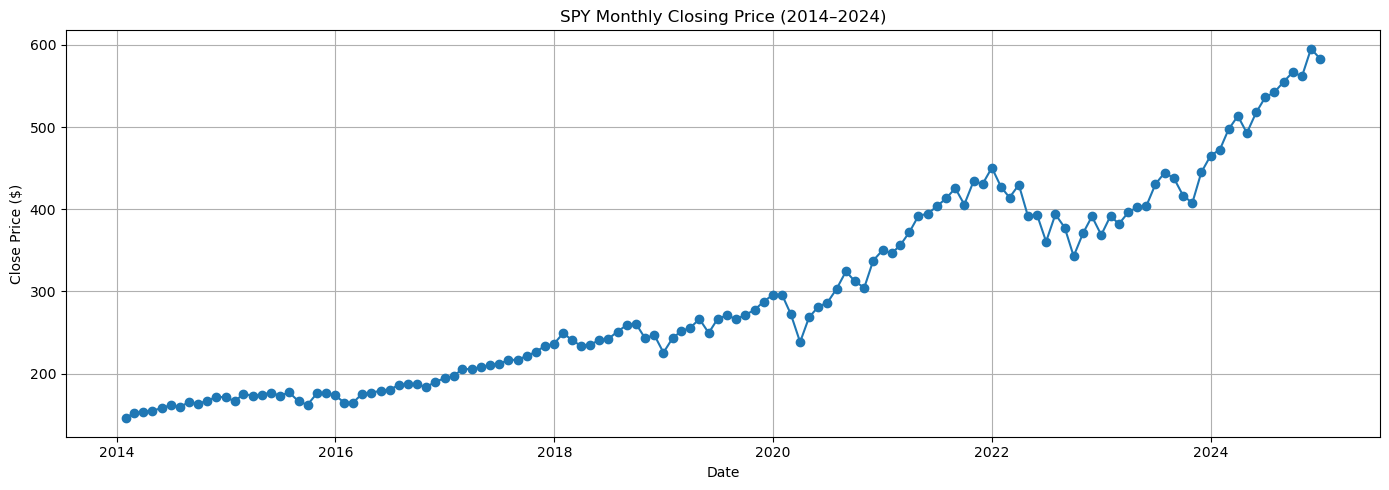

In [139]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure Date is datetime
spy['Date'] = pd.to_datetime(spy['Date'])

# Set index
spy = spy.set_index('Date')

# End-of-month closing price
monthly_price = spy['Close'].resample('M').last()

plt.figure(figsize=(14,5))

plt.plot(monthly_price.index, monthly_price.values, marker='o')

plt.title("SPY Monthly Closing Price (2014–2024)")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [140]:
macro_data

,date,Year_x,Month_x,corecpi,corepce,UNRATE
0,2014-01,2014,01,1.033028,1.309380,6.6
1,2014-02,2014,02,1.145138,0.569520,6.7
2,2014-03,2014,03,2.258584,1.793589,6.7
3,2014-04,2014,04,2.290579,2.072982,6.2
4,2014-05,2014,05,2.337905,2.043780,6.3
...,...,...,...,...,...,...
127,2024-08,2024,08,3.462634,2.139300,4.2
128,2024-09,2024,09,3.801552,3.344326,4.1
129,2024-10,2024,10,3.237494,3.615829,4.1
130,2024-11,2024,11,3.528748,1.267071,4.2


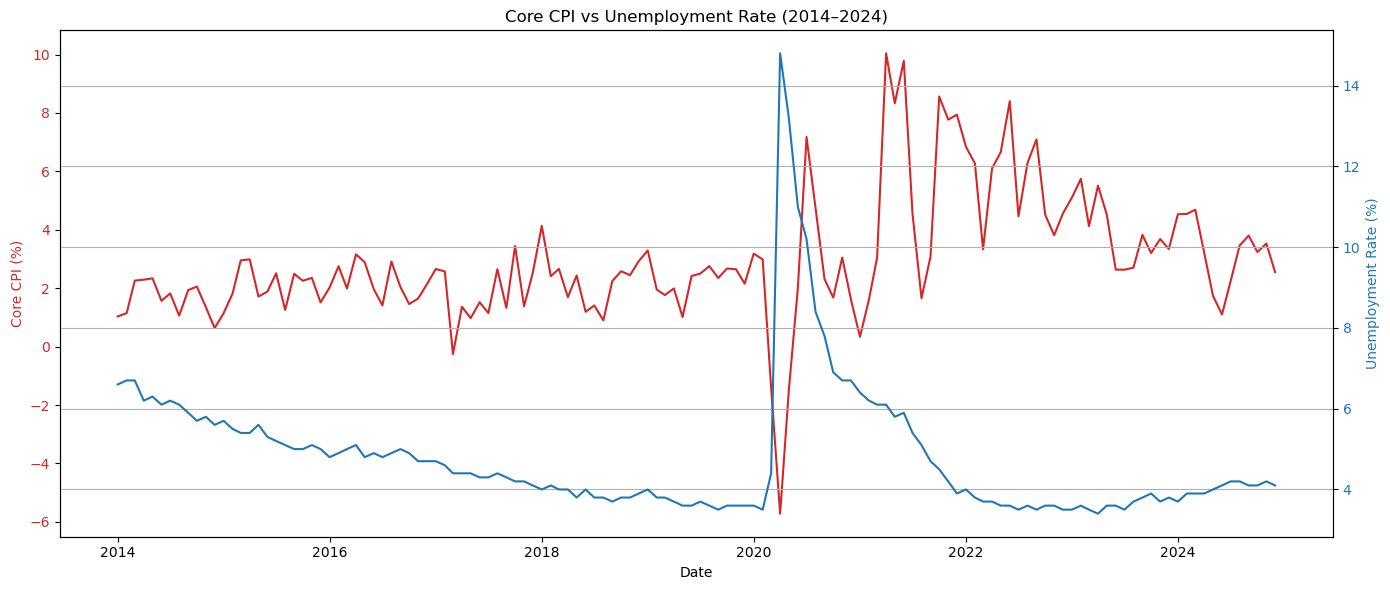

In [141]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure date is datetime
macro_data['date'] = pd.to_datetime(macro_data['date'])

plt.figure(figsize=(14,6))

# First axis (left): core CPI
ax1 = plt.gca()
ax1.plot(macro_data['date'], macro_data['corecpi'], label='Core CPI', color='tab:red')
ax1.set_xlabel("Date")
ax1.set_ylabel("Core CPI (%)", color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

# Second axis (right): unemployment rate
ax2 = ax1.twinx()
ax2.plot(macro_data['date'], macro_data['UNRATE'], label='Unemployment Rate', color='tab:blue')
ax2.set_ylabel("Unemployment Rate (%)", color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title("Core CPI vs Unemployment Rate (2014–2024)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [142]:
stock_rt_df = df.copy()
stock_rt_df = stock_rt_df.drop(columns = ['Open','High','Low','ret'])

#Percentage change in price
stock_rt_df['ret'] = stock_rt_df.groupby('ticker')['Close'].pct_change()

#Merge With market
stock_mkt = (
    market
    .merge(stock_rt_df.assign(Date=pd.to_datetime(stock_rt_df['Date'])),
           on='Date', how='left')
    .sort_values(['ticker', 'Date'])
    .reset_index(drop=True)
)
stock_mkt


,Date,mkt_ret,ticker,sector,Close,Volume,ret
0,2014-01-02,NaN,AAPL,Technology,17.156704,234684800,NaN
1,2014-01-03,-0.000164,AAPL,Technology,16.779840,392467600,-0.021966
2,2014-01-06,-0.002898,AAPL,Technology,16.871340,412610800,0.005453
3,2014-01-07,0.006142,AAPL,Technology,16.750685,317209200,-0.007151
4,2014-01-08,0.000218,AAPL,Technology,16.856762,258529600,0.006333
...,...,...,...,...,...,...,...
166015,2024-12-23,0.005988,ZG,Communication Services,73.379997,334000,-0.005287
166016,2024-12-24,0.011115,ZG,Communication Services,73.800003,200900,0.005724
166017,2024-12-26,0.000067,ZG,Communication Services,73.660004,295400,-0.001897
166018,2024-12-27,-0.010527,ZG,Communication Services,72.739998,248500,-0.012490


In [143]:
stock_fomc = (
    stock_mkt
    .merge(FOMC_rate.assign(Date=pd.to_datetime(FOMC_rate['date'])),
           on='Date', how='left')
    .sort_values(['ticker', 'Date'])
    .reset_index(drop=True)
)
stock_fomc[['Year','Month','Day']] = stock_mkt['Date'].dt.strftime('%Y-%m-%d').str.split('-', expand=True)
macro_data = macro_data.rename(columns={'Year_x':'Year','Month_x':'Month'})
combined_df = stock_fomc.merge(macro_data, on=['Year', 'Month'], how='left')

In [144]:
#final_df = final_df.drop(columns=['date','Year','Month','Day'])
combined_df['is_cut'] = 0
combined_df['is_hike'] = 0
combined_df.loc[combined_df['change_bps']<0,'is_cut'] = 1
combined_df.loc[combined_df['change_bps']>0,'is_hike'] = 1

In [145]:
final_df = combined_df.drop(columns=['year','direction','new_target_range','Target_Low','Target_High','Year','Month','Day'])
sector_dummies = pd.get_dummies(final_df['sector'], prefix='sector')
sector_dummies = sector_dummies.astype(int)

final_df = pd.concat([final_df, sector_dummies], axis=1)
#nvda = final_df[final_df['ticker'] == 'NVDA'].copy()

final_df = final_df.dropna(subset=['mkt_ret','ret'])


In [146]:
final_df.columns

Index(['Date', 'mkt_ret', 'ticker', 'sector', 'Close', 'Volume', 'ret',
       'date_x', 'change_bps', 'date_y', 'corecpi', 'corepce', 'UNRATE',
       'is_cut', 'is_hike', 'sector_Communication Services',
       'sector_Consumer Cyclical', 'sector_Finance', 'sector_Healthcare',
       'sector_Technology', 'sector_Utility'],
      dtype='object')

**Model 1** Baseline Dummy
$$
\text{Stock\_return}_i 
= \alpha 
+ \beta_1 \cdot \text{Market\_return}
+ \beta_2 \cdot \text{is\_hike}
+ \beta_3 \cdot \text{is\_cut}
$$


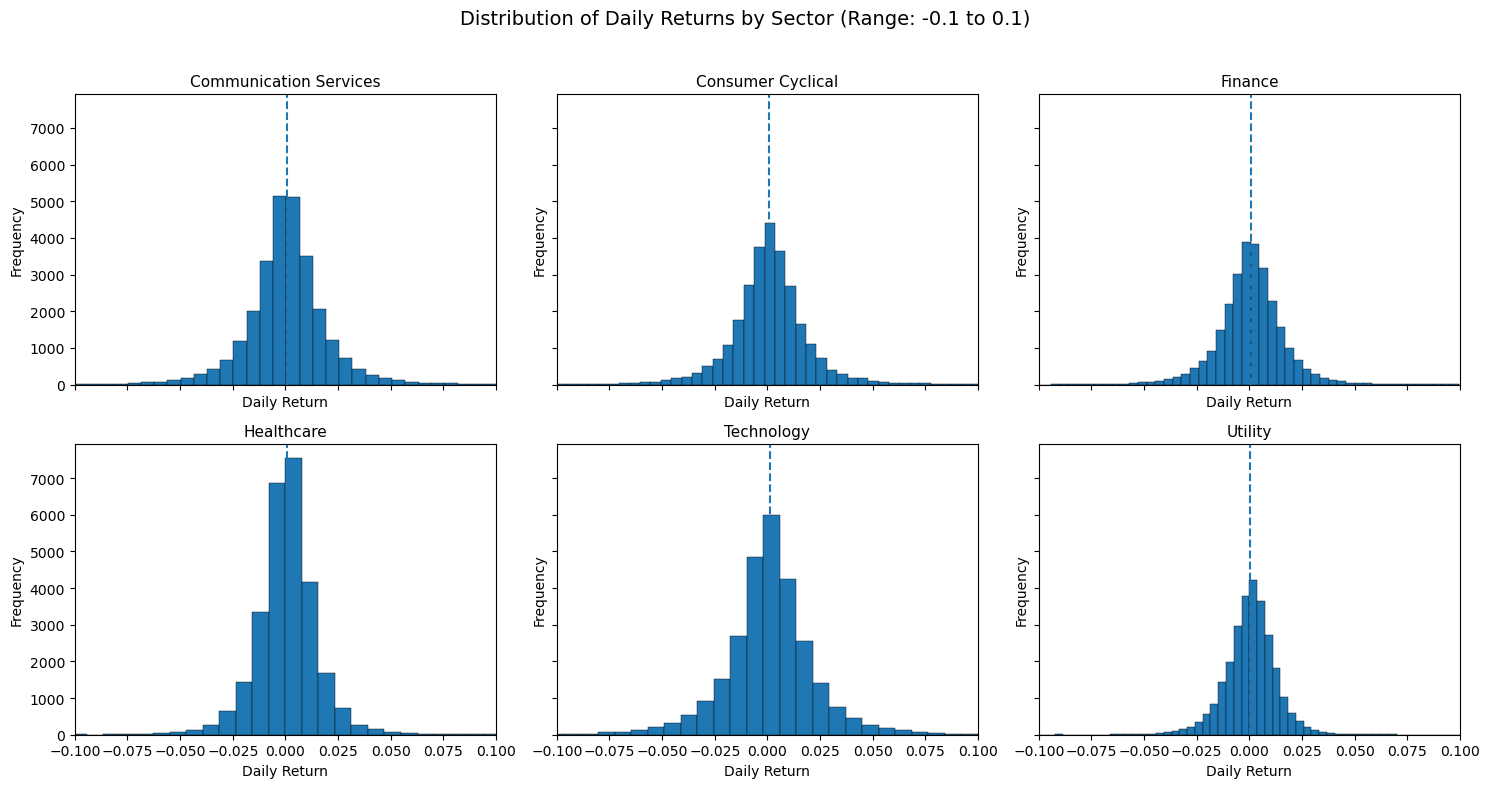

In [147]:
import matplotlib.pyplot as plt
import pandas as pd

# List of sectors (2×3 layout)
sectors = [
    "Communication Services",
    "Consumer Cyclical",
    "Finance",
    "Healthcare",
    "Technology",
    "Utility"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, sec in zip(axes, sectors):
    # Filter returns for this sector
    data = final_df.loc[final_df["sector"] == sec, "ret"].dropna()

    # Histogram with borders and more bins (100)
    ax.hist(
        data,
        bins=100,              # increased number of bins
        edgecolor='black',
        linewidth=0.3
    )
    
    ax.set_title(sec, fontsize=11)
    
    # Add mean line
    ax.axvline(data.mean(), linestyle="--")
    
    # Set X-axis range to [-0.1, 0.1]
    ax.set_xlim(-0.1, 0.1)

    ax.set_xlabel("Daily Return")
    ax.set_ylabel("Frequency")

fig.suptitle("Distribution of Daily Returns by Sector (Range: -0.1 to 0.1)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [148]:
market

,Date,mkt_ret
0,2014-01-02,NaN
1,2014-01-03,-0.000164
2,2014-01-06,-0.002898
3,2014-01-07,0.006142
4,2014-01-08,0.000218
...,...,...
2762,2024-12-23,0.005988
2763,2024-12-24,0.011115
2764,2024-12-26,0.000067
2765,2024-12-27,-0.010527


In [149]:
import statsmodels.api as sm
import pandas as pd

results = []

for ticker, g in final_df.groupby('ticker'):

    # Independent variables
    X = g[['mkt_ret', 'is_hike', 'is_cut']]
    X = sm.add_constant(X)

    # Dependent variable
    y = g['ret']

    # Fit model
    model = sm.OLS(y, X, missing='drop').fit()

    # Save results
    results.append({
        'Ticker': ticker,
        'alpha': model.params.get('const'),
        'beta_mkt': model.params.get('mkt_ret'),
        'gamma_hike': model.params.get('is_hike'),
        'gamma_cut': model.params.get('is_cut'),
        'p_hike': model.pvalues.get('is_hike'),
        'p_cut': model.pvalues.get('is_cut'),
        'r2': model.rsquared
    })

results_df = pd.DataFrame(results)
results_df

,Ticker,alpha,beta_mkt,gamma_hike,gamma_cut,p_hike,p_cut,r2
0,AAPL,0.000475,1.192900,-0.001833,0.002319,0.495845,0.584565,0.536878
1,ABBV,0.000366,0.710369,0.001147,-0.007807,0.730481,0.136922,0.212571
2,ABT,0.000106,0.859433,-0.000463,-0.001084,0.852988,0.782902,0.411628
3,AEP,0.000171,0.505025,0.002131,0.004239,0.419901,0.308715,0.176633
4,AMD,0.000916,1.650632,0.004206,0.008223,0.551349,0.459885,0.243176
5,AMGN,0.000039,0.797361,0.002642,0.008970,0.367171,0.052127,0.303255
6,AMZN,0.000393,1.181427,0.002322,0.007839,0.524809,0.173135,0.381098
7,AVGO,0.001002,1.400749,-0.000098,-0.008506,0.980428,0.174907,0.423208
8,AXP,0.000022,1.220564,-0.005440,0.004112,0.072712,0.389390,0.489954
9,BAC,-0.000015,1.240169,-0.002356,-0.009776,0.442065,0.043031,0.492929


**Model 2** Abnormal Return
$$
Return_{i,t} = \alpha_i + \beta_i Market_{t} + \varepsilon_{i,t}
$$


$$
Abnormal Return_{i,t} 
= Return_{i,t} - \left( \hat{\alpha}_i + \hat{\beta}_i Market_{m,t} \right)
$$


$$
Abnormal Return_{i,t}
= \gamma_0
+ \gamma_1 \,\text{is\_hike}_t
+ \gamma_2 \,\text{is\_cut}_t
+ u_{i,t}
$$


In [150]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Sort first
final_df = final_df.sort_values(['ticker', 'Date']).copy()

# Initialize AR as float
final_df['AR'] = np.nan

# -------- 1) Market model per (ticker, sector) to get AR --------
for (ticker, sector), g in final_df.groupby(['ticker', 'sector']):
    X = sm.add_constant(g['mkt_ret'])
    y = g['ret']
    
    mm = sm.OLS(y, X, missing='drop').fit()
    
    # Abnormal return = actual - predicted
    final_df.loc[g.index, 'AR'] = y - mm.predict(X)

# -------- 2) AR regression on FOMC dummies & change_bps per ticker --------
ar_results = []

for ticker, g in final_df.groupby('ticker'):
    
    y = g['AR'].astype(float)
    
    X = g[['is_cut', 'is_hike', 'change_bps']]
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X, missing='drop').fit()
    
    ar_results.append({
        'Ticker': ticker,
        'Sector': g['sector'].iloc[0],   # sector from this ticker's group
        
        # effects
        'gamma_hike':   model.params.get('is_hike',    np.nan),
        'gamma_cut':    model.params.get('is_cut',     np.nan),
        'gamma_change': model.params.get('change_bps', np.nan),
        
        # p-values
        'p_hike':   model.pvalues.get('is_hike',    np.nan),
        'p_cut':    model.pvalues.get('is_cut',     np.nan),
        'p_change': model.pvalues.get('change_bps', np.nan),
        
        'r2': model.rsquared
    })

ar_results_df = pd.DataFrame(ar_results)
ar_results_df


,Ticker,Sector,gamma_hike,gamma_cut,gamma_change,p_hike,p_cut,p_change,r2
0,AAPL,Technology,0.005259,-0.005286,-0.000188,0.251563,0.293362,0.075079,0.143424
1,ABBV,Healthcare,-0.012920,0.011155,0.000423,0.255297,0.369202,0.104393,0.119652
2,ABT,Healthcare,-0.001149,0.000673,0.000031,0.706164,0.840742,0.650158,0.009791
3,AEP,Utility,-0.003031,0.005208,0.000078,0.553733,0.356987,0.498044,0.024280
4,AMD,Technology,0.021444,-0.017934,-0.000555,0.054172,0.136811,0.029116,0.179832
5,AMGN,Healthcare,0.000553,0.003224,-0.000047,0.897837,0.497765,0.631471,0.078300
6,AMZN,Consumer Cyclical,0.019366,-0.016571,-0.000531,0.009904,0.039455,0.002363,0.324106
7,AVGO,Technology,-0.001557,-0.001168,0.000113,0.790569,0.856207,0.398762,0.092119
8,AXP,Finance,0.000813,-0.001385,-0.000150,0.853164,0.774248,0.138438,0.205868
9,BAC,Finance,-0.005446,0.001640,0.000186,0.368069,0.803722,0.179041,0.114988


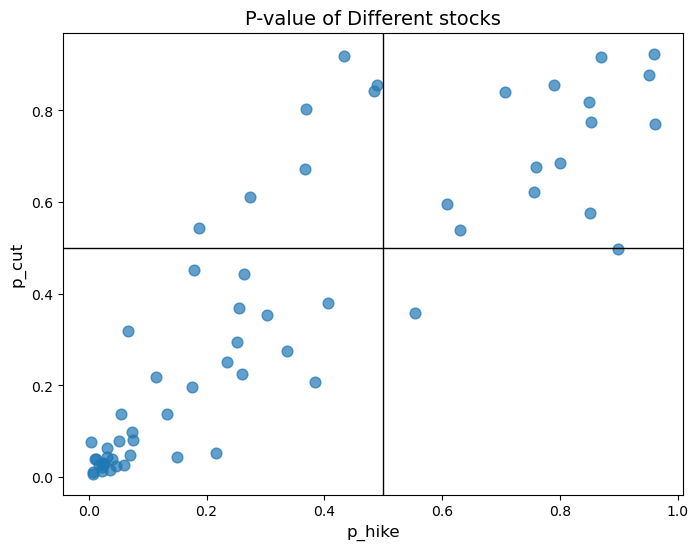

In [151]:
import matplotlib.pyplot as plt
def p_value_plot(df):
    plt.figure(figsize=(8,6))

    plt.scatter(df['p_hike'], df['p_cut'], s=60, alpha=0.7)

    # Center lines at 0.5
    plt.axvline(0.5, color='black', linewidth=1)
    plt.axhline(0.5, color='black', linewidth=1)

    plt.xlabel('p_hike', fontsize=12)
    plt.ylabel('p_cut', fontsize=12)
    plt.title('P-value of Different stocks', fontsize=14)

    plt.grid(False)
    plt.show()

p_value_plot(ar_results_df)

In [152]:
df = ar_results_df.copy()

df['sig_hike'] = df['p_hike'] < 0.2
df['sig_cut']  = df['p_cut']  < 0.2

def label_row(row):
    if row['sig_hike'] and row['sig_cut']:
        return 'Both'
    elif row['sig_hike']:
        return 'Hike Only'
    elif row['sig_cut']:
        return 'Cut Only'
    else:
        return 'Not Significant'
    
df['sig_category'] = df.apply(label_row, axis=1)

sector_counts = (
    df.groupby(['Sector', 'sig_category'])['Ticker']
      .count()
      .reset_index()
      .pivot(index='Sector', columns='sig_category', values='Ticker')
      .fillna(0)
)

sector_counts


sig_category,Both,Cut Only,Hike Only,Not Significant
Sector,,,,
Communication Services,6.0,0.0,1.0,3.0
Consumer Cyclical,3.0,0.0,2.0,5.0
Finance,0.0,0.0,1.0,9.0
Healthcare,3.0,1.0,0.0,6.0
Technology,4.0,0.0,0.0,6.0
Utility,8.0,0.0,0.0,2.0


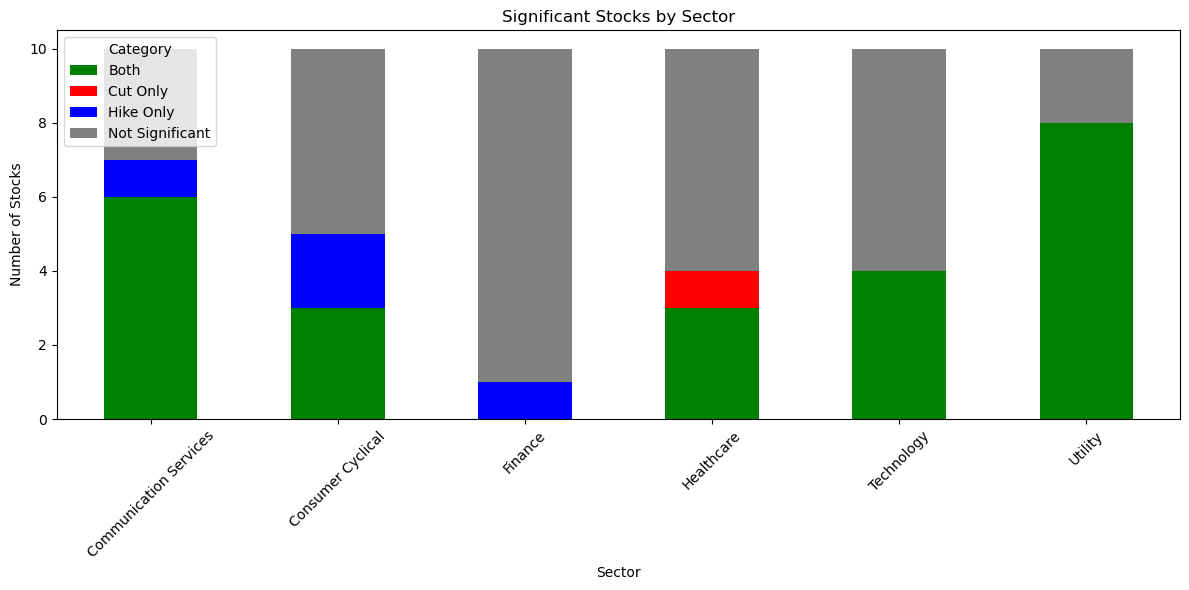

In [153]:
import matplotlib.pyplot as plt

sector_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    color=['green','red','blue','gray']
)

plt.title("Significant Stocks by Sector")
plt.ylabel("Number of Stocks")
plt.legend(title="Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/var/folders/fj/pxz8d_45589622lsp3n_9t4h0000gn/T/ipykernel_7309/2834818262.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


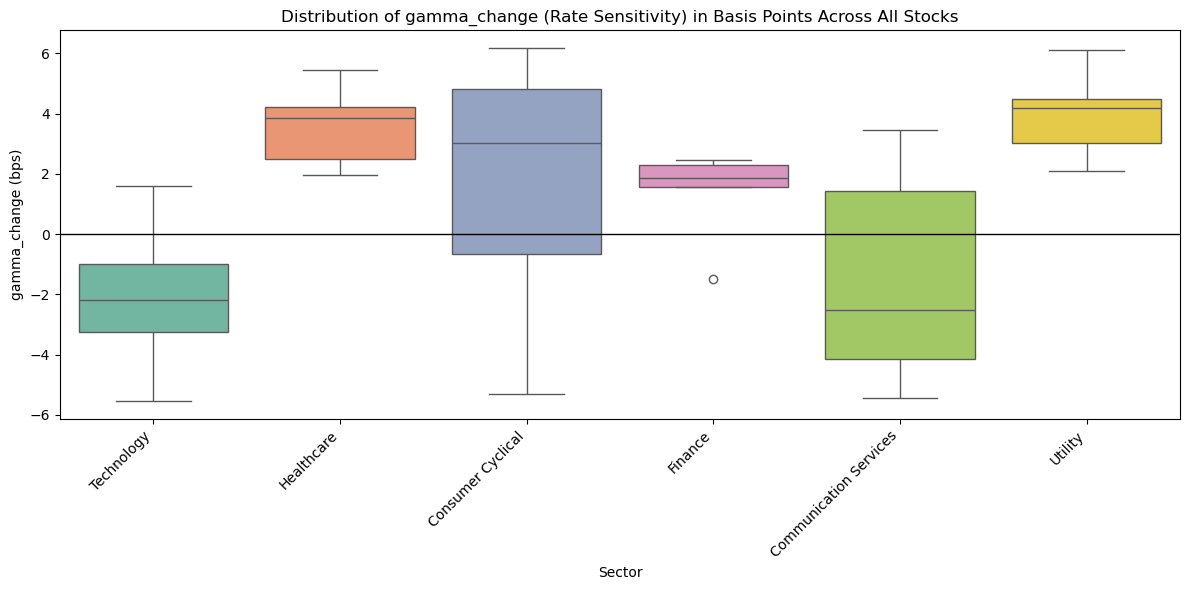

In [154]:
import seaborn as sns
import matplotlib.pyplot as plt

def gamma_boxplot(df):
    df_bps = df.copy()
    df_bps = df_bps[df_bps['p_change']<0.2]
    df_bps['gamma_change_bps'] = df_bps['gamma_change'] * 10000   # convert to bps

    plt.figure(figsize=(12,6))

    sns.boxplot(
        data=df_bps,
        x='Sector',
        y='gamma_change_bps',
        palette='Set2'
    )

    plt.title("Distribution of gamma_change (Rate Sensitivity) in Basis Points Across All Stocks")
    plt.ylabel("gamma_change (bps)")
    plt.xlabel("Sector")
    plt.xticks(rotation=45, ha='right')

    plt.axhline(0, color='black', linewidth=1)   # helpful reference line

    plt.tight_layout()
    plt.show()

gamma_boxplot(ar_results_df)


**Visualizations**: Average returns across time

In [155]:
events = FOMC_rate[['date','direction']]
events = events.rename(columns={'direction':'event_type','date':'Date'})
events['Date'] = pd.to_datetime(events['Date'])

import pandas as pd

def compute_avg_returns_event_window(
    final_df,
    events,
    pre_days=10,
    post_days=10,
    date_col='Date',
    ret_col='ret',
    group_cols=None,
):
    """
    Compute average returns within a pre/post window around events
    vs all other days.

    Parameters
    ----------
    final_df : pd.DataFrame
        Main data with returns (must contain `date_col` and `ret_col`).
    events : pd.DataFrame
        Event dates and types (must contain `date_col` and 'event_type').
    pre_days : int
        Number of days before the event to include (e.g. 10 for -10).
    post_days : int
        Number of days after the event to include (e.g. 10 for +10).
    date_col : str
        Name of the date column in both DataFrames (default 'Date').
    ret_col : str
        Name of the return column in `final_df` (default 'ret').
    group_cols : list or None
        Extra columns to group by (e.g. ['sector']). If None, only day_group.

    Returns
    -------
    pd.DataFrame
        Average returns by group_cols + day_group, where day_group is:
        - '{event_type}_window' (e.g. 'hike_window', 'cut_window')
        - 'other' (not in any event window)
    """

    df = final_df.copy()
    ev = events.copy()

    # Ensure datetime
    df[date_col] = pd.to_datetime(df[date_col])
    ev[date_col] = pd.to_datetime(ev[date_col])

    # Build window labels: for each event, mark all dates in [T-pre, T+post]
    window_list = []

    for _, row in ev.iterrows():
        event_date = row[date_col]
        etype = row['event_type']

        start = event_date - pd.Timedelta(days=pre_days)
        end = event_date + pd.Timedelta(days=post_days)

        tmp = df.loc[(df[date_col] >= start) & (df[date_col] <= end), [date_col]].drop_duplicates()
        tmp['day_group'] = f'{etype}_window'   # e.g. 'hike_window', 'cut_window'
        window_list.append(tmp)

    if window_list:
        window_df = pd.concat(window_list, ignore_index=True)
        # If a date appears in multiple windows, keep the last label (you can change this logic)
        window_df = window_df.drop_duplicates(subset=[date_col], keep='last')
    else:
        window_df = pd.DataFrame(columns=[date_col, 'day_group'])

    # Merge window labels back to main df
    df = df.merge(window_df, on=date_col, how='left')
    df['day_group'] = df['day_group'].fillna('other')

    # Build group-by columns
    if group_cols is None:
        gb_cols = ['day_group']
    else:
        gb_cols = list(group_cols) + ['day_group']

    result = (
        df.groupby(gb_cols)[ret_col]
          .mean()
          .reset_index()
          .rename(columns={ret_col: 'avg_return'})
    )

    return result


In [156]:
# Define 10-day bins from -60 to +60
bins = [(i, i+10) for i in range(-60, 60, 10)]
labels = [f"{low} to {high}" for low, high in bins]

def build_tau_panel(final_df, events, tau_min=-60, tau_max=60):
    df = final_df.copy()
    ev = events.copy()

    df['Date'] = pd.to_datetime(df['Date'])
    ev['Date'] = pd.to_datetime(ev['Date'])

    rows = []

    for _, e in ev.iterrows():
        event_date = e['Date']
        etype = e['event_type']

        start = event_date + pd.Timedelta(days=tau_min)
        end   = event_date + pd.Timedelta(days=tau_max)

        mask = (df['Date'] >= start) & (df['Date'] <= end)
        tmp = df.loc[mask, ['Date', 'sector', 'ret']].copy()

        if tmp.empty:
            continue

        tmp['tau'] = (tmp['Date'] - event_date).dt.days
        tmp['event_type'] = etype
        rows.append(tmp)

    if not rows:
        return pd.DataFrame(columns=['sector','event_type','tau','ret'])

    return pd.concat(rows, ignore_index=True)


tau_panel = build_tau_panel(final_df, events, -60, 60)

def assign_bin(tau):
    for low, high in bins:
        if low <= tau < high:
            return f"{low} to {high}"
    return None

tau_panel['bin'] = tau_panel['tau'].apply(assign_bin)

bin_avg = (
    tau_panel.groupby(['sector','event_type','bin'])['ret']
             .mean()
             .reset_index()
)

bin_avg['ret_bps'] = bin_avg['ret'] * 10000

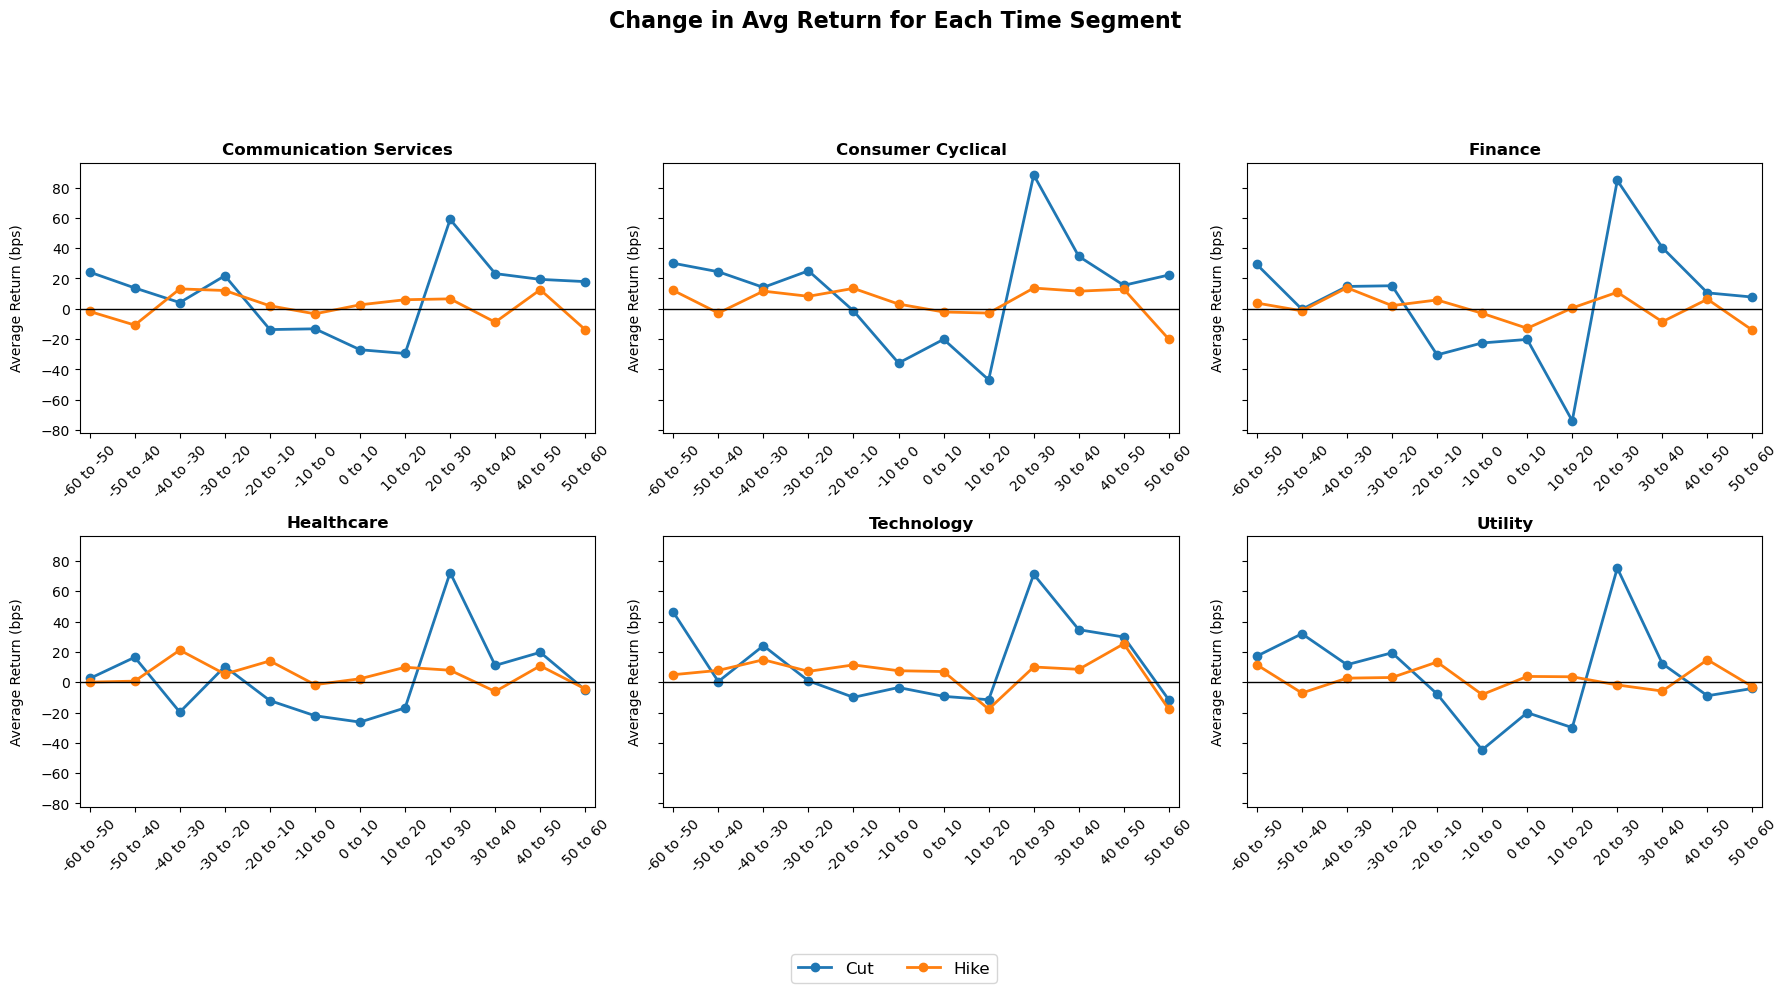

In [157]:
import numpy as np
import matplotlib.pyplot as plt

# define sectors and event types from the actual data
sectors = sorted(bin_avg['sector'].unique())
event_types = sorted(bin_avg['event_type'].unique())  # e.g. ['hike','cut'] or ['Hike','Cut']

# x and labels already defined from your bins
# bins = [(i, i+10) for i in range(-60, 60, 10)]
# labels = [f"{low} to {high}" for low, high in bins]
x = np.arange(len(labels))

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.flatten()

for ax, sector in zip(axes, sectors):
    sub = bin_avg[bin_avg['sector'] == sector]

    if sub.empty:
        ax.set_visible(False)
        continue

    for etype in event_types:
        tmp = (
            sub[sub['event_type'] == etype]
            .set_index('bin')
            .reindex(labels)        # ensure all bins present in this order
        )

        # only plot if at least some data exist
        if tmp['ret_bps'].notna().any():
            ax.plot(
                x,
                tmp['ret_bps'].to_numpy(),
                marker='o',
                linewidth=2,
                label=str(etype).capitalize()
            )

    ax.set_title(str(sector), fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45)
    ax.axhline(0, color='black', linewidth=1)
    ax.grid(False)
    ax.margins(x=0.02)
    ax.set_ylabel('Average Return (bps)', labelpad=12)

# hide unused axes if you have fewer than 6 sectors
for ax in axes[len(sectors):]:
    ax.set_visible(False)

fig.suptitle("Change in Avg Return for Each Time Segment",
             fontsize=16, fontweight='bold')

plt.subplots_adjust(left=0.12, top=0.92)

# shared legend from all axes
handles, labels_leg = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in labels_leg:
            handles.append(hh)
            labels_leg.append(ll)

fig.legend(handles, labels_leg, loc='lower center', ncol=2, fontsize=12)

plt.tight_layout(rect=[0, 0.1, 1, 0.9])
plt.show()


**Model 3: Volatility Model**
$$
r_{i,t}^2
= \alpha_i
+ \gamma_{hike}\, is\_hike_t
+ \gamma_{cut}\, is\_cut_t
+ \gamma_{change}\, \Delta rate_t
+ u_{i,t}
$$


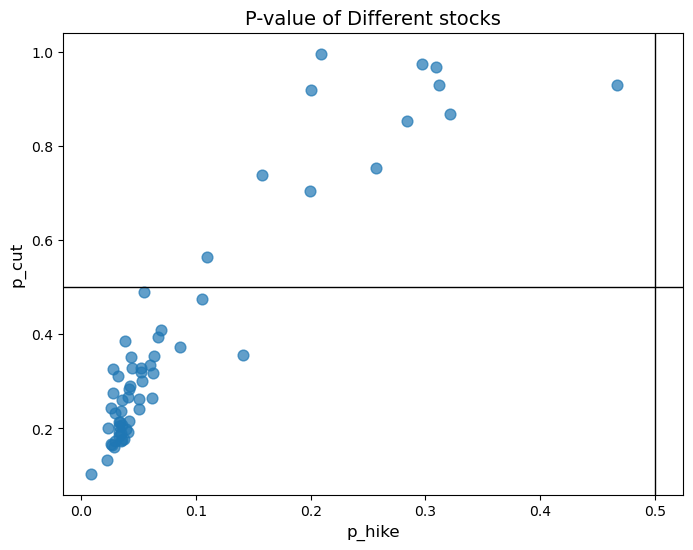

In [158]:
import numpy as np
import statsmodels.api as sm

# Squared returns as volatility proxy
final_df['ret_sq'] = final_df['ret']**2   # CURRENT (in decimal squared units)

vol_results = []

for ticker, g in final_df.groupby('ticker'):
    g = g.dropna(subset=['ret_sq', 'is_hike', 'is_cut', 'change_bps'])
    if g.empty:
        continue
    
    y = g['ret_sq'].astype(float)
    X = g[['is_hike', 'is_cut', 'change_bps']]
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X).fit()
    
    vol_results.append({
        'Ticker': ticker,
        'Sector': g['sector'].iloc[0],

        'gamma_hike':   model.params.get('is_hike', np.nan),
        'gamma_cut':    model.params.get('is_cut', np.nan),
        'gamma_change': model.params.get('change_bps', np.nan),

        'p_hike':   model.pvalues.get('is_hike', np.nan),
        'p_cut':    model.pvalues.get('is_cut', np.nan),
        'p_change': model.pvalues.get('change_bps', np.nan),

        'r2': model.rsquared
    })

vol_results_df = pd.DataFrame(vol_results)
p_value_plot(vol_results_df)


In [179]:
stock_rt_df

,Date,ticker,sector,Close,Volume,ret
0,2014-01-02,AAPL,Technology,17.156704,234684800,NaN
1,2014-01-03,AAPL,Technology,16.779840,392467600,-0.021966
2,2014-01-06,AAPL,Technology,16.871340,412610800,0.005453
3,2014-01-07,AAPL,Technology,16.750685,317209200,-0.007151
4,2014-01-08,AAPL,Technology,16.856762,258529600,0.006333
...,...,...,...,...,...,...
166015,2024-12-23,DHR,Healthcare,227.778458,2798800,0.002669
166016,2024-12-24,DHR,Healthcare,229.358871,988300,0.006938
166017,2024-12-26,DHR,Healthcare,229.885696,1512400,0.002297
166018,2024-12-27,DHR,Healthcare,229.975250,2130400,0.000390


/var/folders/fj/pxz8d_45589622lsp3n_9t4h0000gn/T/ipykernel_7309/2834818262.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


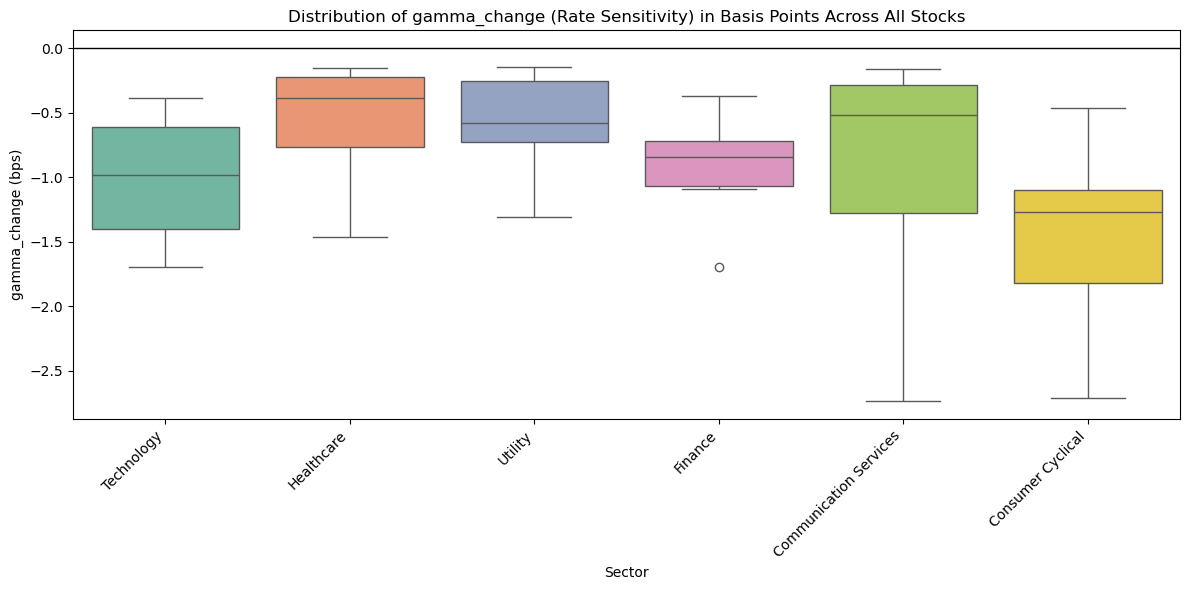

In [159]:
gamma_boxplot(vol_results_df)

In [160]:
import pandas as pd

# 0-day window (event day only)
vol_0 = compute_avg_returns_event_window(
    final_df,
    events,
    pre_days=0,
    post_days=0,
    date_col='Date',
    ret_col='ret_sq',
    group_cols=None
).rename(columns={'avg_return': 'avg_vol'})
vol_0['window'] = '0'

# ±5-day window
vol_5 = compute_avg_returns_event_window(
    final_df,
    events,
    pre_days=5,
    post_days=5,
    date_col='Date',
    ret_col='ret_sq',
    group_cols=None
).rename(columns={'avg_return': 'avg_vol'})
vol_5['window'] = '±5'

# ±10-day window
vol_10 = compute_avg_returns_event_window(
    final_df,
    events,
    pre_days=10,
    post_days=10,
    date_col='Date',
    ret_col='ret_sq',
    group_cols=None
).rename(columns={'avg_return': 'avg_vol'})
vol_10['window'] = '±10'

# ±30-day window
vol_30 = compute_avg_returns_event_window(
    final_df,
    events,
    pre_days=30,
    post_days=30,
    date_col='Date',
    ret_col='ret_sq',
    group_cols=None
).rename(columns={'avg_return': 'avg_vol'})
vol_30['window'] = '±30'

# Combine everything
vol_all = pd.concat([vol_0, vol_5, vol_10, vol_30], ignore_index=True)

# from variance (avg_vol) to std dev in basis points
vol_all['avg_vol_bps'] = np.sqrt(vol_all['avg_vol']) * 10000
vol_all.head()


,day_group,avg_vol,window,avg_vol_bps
0,Cut_window,0.002955,0,543.619539
1,Hike_window,0.000557,0,236.021446
2,other,0.000370,0,192.290569
3,Cut_window,0.001625,±5,403.053175
4,Hike_window,0.000399,±5,199.789873


$$
\mathrm{avgVol\_bps} = 10000 \,\sqrt{\mathrm{avgVol}}
$$


     day_group   avg_vol window  avg_vol_bps
0   Cut_window  0.002955      0   543.619539
1  Hike_window  0.000557      0   236.021446
2        other  0.000370      0   192.290569
3   Cut_window  0.001625     ±5   403.053175
4  Hike_window  0.000399     ±5   199.789873
Index(['day_group', 'avg_vol', 'window', 'avg_vol_bps'], dtype='object')


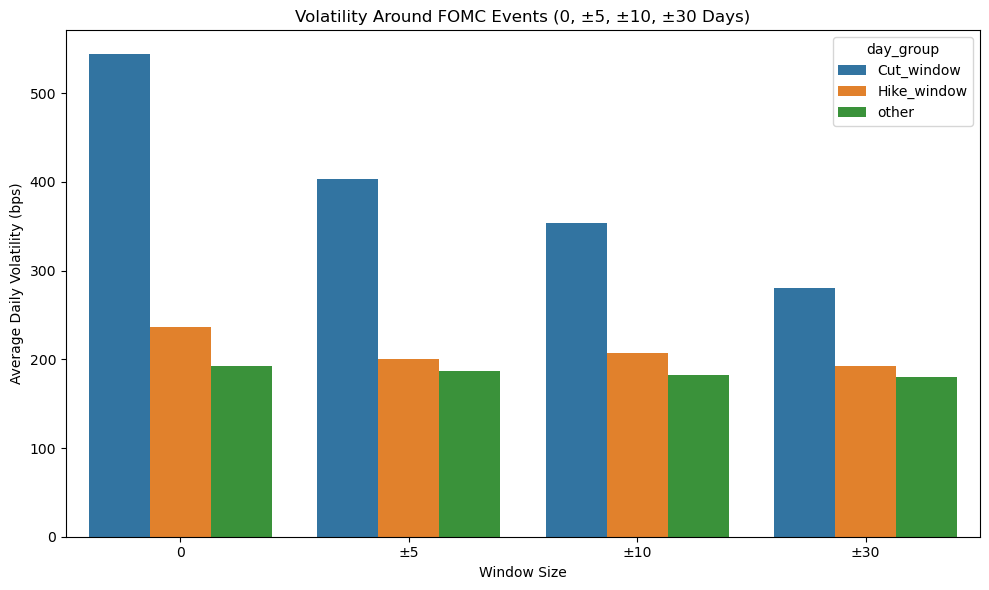

In [161]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Make a copy and create the bps volatility column
vol_all = vol_all.copy()
vol_all['avg_vol_bps'] = np.sqrt(vol_all['avg_vol'].astype(float)) * 10000  # std dev in bps

print(vol_all.head())      # optional: sanity check
print(vol_all.columns)     # should now include 'avg_vol_bps'

# 2) Barplot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=vol_all,
    x='window',
    y='avg_vol_bps',
    hue='day_group',              # 'cut_window', 'hike_window', 'other'
    order=['0', '±5', '±10', '±30']   # only if all these exist; otherwise you can drop 'order='
)

plt.xlabel("Window Size")
plt.ylabel("Average Daily Volatility (bps)")
plt.title("Volatility Around FOMC Events (0, ±5, ±10, ±30 Days)")
plt.tight_layout()
plt.show()


**Model 4 GARCH(1,1)**

$$
\begin{aligned}
r_t 
&= \mu 
+ \beta_{\text{hike}}\,\text{is\_hike}_t
+ \beta_{\text{cut}}\,\text{is\_cut}_t
+ \beta_{\Delta r}\,\Delta\text{rate}_t
+ \varepsilon_t, 
\qquad \varepsilon_t = z_t \sqrt{h_t},
\\[6pt]
h_t 
&= \omega 
+ \alpha\,\varepsilon_{t-1}^2 
+ \beta\,h_{t-1},
\qquad z_t \sim N(0,1).
\end{aligned}
$$


$$
h_t = \omega + \alpha \varepsilon_{t-1}^2 + \beta h_{t-1}
$$

Interpretation:

- omega (ω): baseline variance, the long-run minimum level of volatility.

- alpha (α): shock sensitivity. A larger alpha means that large shocks
  (large epsilon_{t-1}^2) lead to a bigger increase in next-day volatility.

- beta (β): volatility persistence. A larger beta means today’s volatility
  is heavily influenced by yesterday’s volatility.

- alpha + beta: total persistence of volatility.
  - If alpha + beta is close to 1 → very persistent volatility, long clusters.
  - If alpha + beta is much less than 1 → volatility mean-reverts quickly.
  - If alpha + beta ≥ 1 → volatility may be non-stationary or explosive.


In [162]:
from arch import arch_model
import pandas as pd
import numpy as np

# Sort and pick just the columns we need
garch_df = final_df.sort_values('Date').copy()

# Use market return as the series to model
# (you can switch this to a specific ticker later)
y = garch_df['mkt_ret'].astype(float)

# Optional but recommended: scale to percent to help optimization
y_pct = y * 100

# Exogenous regressors in the MEAN equation: hikes, cuts, rate changes
X = garch_df[['is_hike', 'is_cut', 'change_bps']].astype(float)


In [163]:
# Only hikes and cuts, no change_bps
X_hc = garch_df[['is_hike', 'is_cut']]

am_hc = arch_model(
    y,
    x=X_hc,
    mean='ARX',
    lags=0,
    vol='GARCH',
    p=1, q=1,
    dist='normal'
)
res_hc = am_hc.fit(update_freq=10, disp='off')
print(res_hc.summary())


/opt/anaconda3/lib/python3.12/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001159. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/var/folders/fj/pxz8d_45589622lsp3n_9t4h0000gn/T/ipykernel_7309/2658979802.py:13: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  res_hc = am_hc.fit(update_freq=10, disp='off')


                          AR-X - GARCH Model Results                          
Dep. Variable:                mkt_ret   R-squared:                       0.005
Mean Model:                      AR-X   Adj. R-squared:                  0.005
Vol Model:                      GARCH   Log-Likelihood:                626649.
Distribution:                  Normal   AIC:                      -1.25329e+06
Method:            Maximum Likelihood   BIC:                      -1.25323e+06
                                        No. Observations:               165960
Date:                Fri, Dec 12 2025   Df Residuals:                   165957
Time:                        10:39:44   Df Model:                            3
                                   Mean Model                                  
                  coef    std err          t      P>|t|        95.0% Conf. Int.
-------------------------------------------------------------------------------
Const       6.2809e-04  2.285e-05     27.483 2.77

$$
h_t = \omega + \alpha \varepsilon_{t-1}^2 + \beta h_{t-1}
$$

Interpretation:

- omega (ω): baseline variance, the long-run minimum level of volatility.

- alpha (α): shock sensitivity. A larger alpha means that large shocks
  (large epsilon_{t-1}^2) lead to a bigger increase in next-day volatility.

- beta (β): volatility persistence. A larger beta means today’s volatility
  is heavily influenced by yesterday’s volatility.

- alpha + beta: total persistence of volatility.
  - If alpha + beta is close to 1 → very persistent volatility, long clusters.
  - If alpha + beta is much less than 1 → volatility mean-reverts quickly.
  - If alpha + beta ≥ 1 → volatility may be non-stationary or explosive.


GARCH obtains conditional volatility by recursively updating a conditional variance equation using last period’s squared shock and last period’s variance.

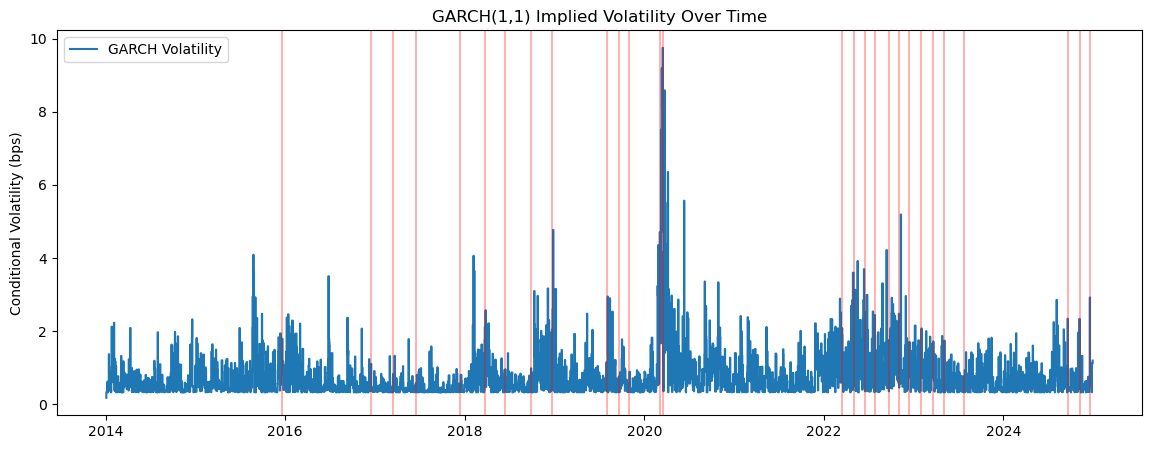

In [164]:
import matplotlib.pyplot as plt

garch_df['cond_vol_pct'] = res_hc.conditional_volatility
garch_df['cond_vol_bps'] = garch_df['cond_vol_pct'] * 100

plt.figure(figsize=(14,5))
plt.plot(garch_df['Date'], garch_df['cond_vol_bps'], label='GARCH Volatility')
for d in events['Date']:
    plt.axvline(d, color='red', alpha=0.3)

plt.ylabel('Conditional Volatility (bps)')
plt.title('GARCH(1,1) Implied Volatility Over Time')
plt.legend()
plt.show()




In [165]:
import pandas as pd

# 1) Equal-weighted sector return per day
sector_ret = (
    final_df
    .groupby(['Date', 'sector'])['ret']
    .mean()
    .reset_index()
)

# 2) Get one row per date for FOMC variables
fomc_daily = (
    final_df[['Date', 'is_hike', 'is_cut', 'change_bps']]
    .drop_duplicates(subset='Date')
    .sort_values('Date')
)

# 3) Merge FOMC info onto sector returns
sector_ret = (
    sector_ret
    .merge(fomc_daily, on='Date', how='left')
    .sort_values(['sector', 'Date'])
)
from arch import arch_model
import numpy as np

garch_sector_results = []

for sector, g in sector_ret.groupby('sector'):
    # Drop missing values
    g = g.dropna(subset=['ret', 'is_hike', 'is_cut', 'change_bps'])
    if g.empty:
        continue
    
    # Return series in %
    y = g['ret'].astype(float) * 100
    
    # Exogenous regressors in the mean equation
    X = g[['is_hike', 'is_cut', 'change_bps']].astype(float)

    # GARCH(1,1) with ARX mean
    am = arch_model(
        y,
        x=X,
        mean='ARX',   # constant + exog
        lags=0,
        vol='GARCH',
        p=1, q=1,
        dist='normal'
    )

    res = am.fit(update_freq=20, disp='off')
    
    # Store key parameters
    params = res.params
    alpha = params.get('alpha[1]', np.nan)
    beta  = params.get('beta[1]',  np.nan)
    
    garch_sector_results.append({
        'sector': sector,
        'omega': params.get('omega', np.nan),
        'alpha': alpha,
        'beta': beta,
        'alpha_plus_beta': alpha + beta if np.isfinite(alpha) and np.isfinite(beta) else np.nan,
        'beta_hike': params.get('is_hike', np.nan),
        'beta_cut': params.get('is_cut', np.nan),
        'beta_change_bps': params.get('change_bps', np.nan)
    })

garch_sector_df = pd.DataFrame(garch_sector_results)


In [166]:
garch_sector_df

,sector,omega,alpha,beta,alpha_plus_beta,beta_hike,beta_cut,beta_change_bps
0,Communication Services,1.940554,0.994884,5.116148e-03,1.0,0.358569,-0.767471,-0.015538
1,Consumer Cyclical,1.669153,0.979650,2.034992e-02,1.0,-0.861882,0.588215,0.014244
2,Finance,2.479355,1.000000,0.000000e+00,1.0,-0.316158,-0.250443,-0.004978
3,Healthcare,1.021559,1.000000,0.000000e+00,1.0,-1.133055,1.445726,0.016594
4,Technology,2.237328,0.976613,2.338743e-02,1.0,0.731177,-1.302849,-0.025835
5,Utility,0.960836,1.000000,4.951208e-09,1.0,-0.788941,1.302193,0.007455


In [167]:
from arch import arch_model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 1) Sector-level equal-weighted returns
sector_ret = (
    final_df
    .groupby(['Date', 'sector'])['ret']
    .mean()
    .reset_index()
)

# 2) One row per date for FOMC variables
fomc_daily = (
    final_df[['Date', 'is_hike', 'is_cut', 'change_bps']]
    .drop_duplicates(subset='Date')
    .sort_values('Date')
)

# 3) Merge FOMC info onto sector returns
sector_ret = (
    sector_ret
    .merge(fomc_daily, on='Date', how='left')
    .sort_values(['sector', 'Date'])
)

# Make sure events['Date'] is datetime and event_type is clean
events_plot = events.copy()
events_plot['Date'] = pd.to_datetime(events_plot['Date'])
events_plot['event_type'] = events_plot['event_type'].str.lower()

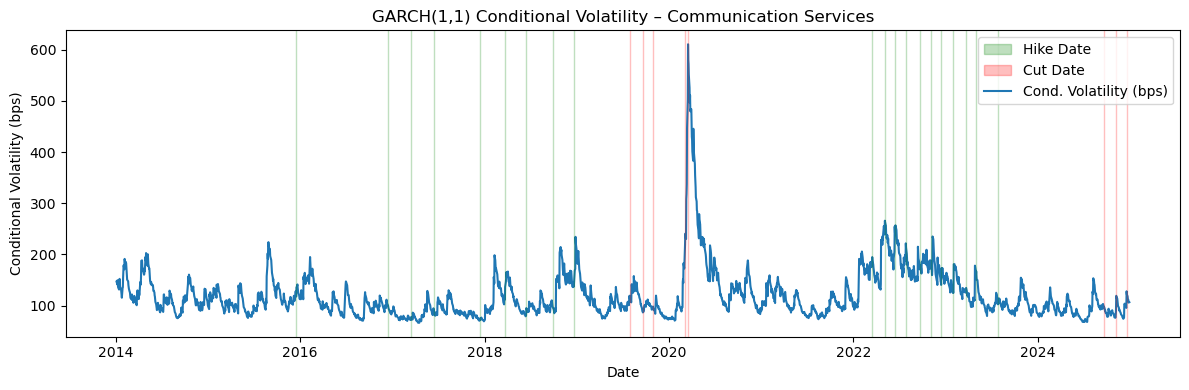

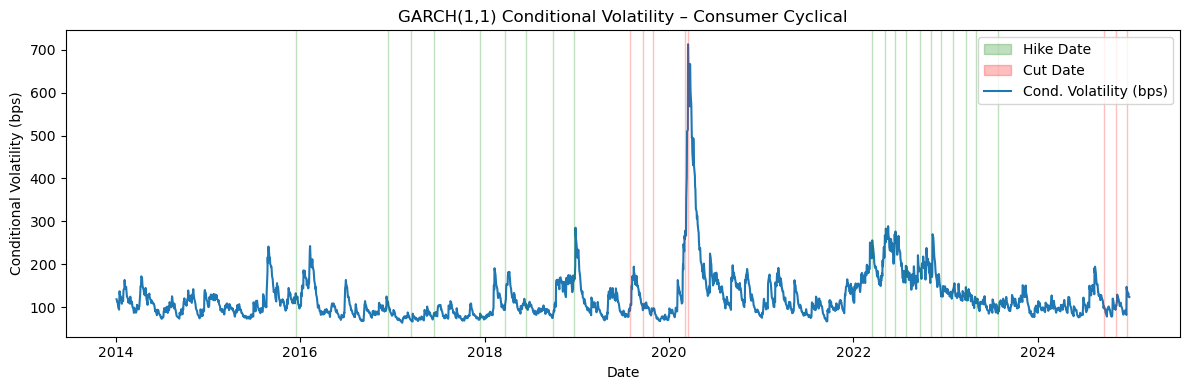

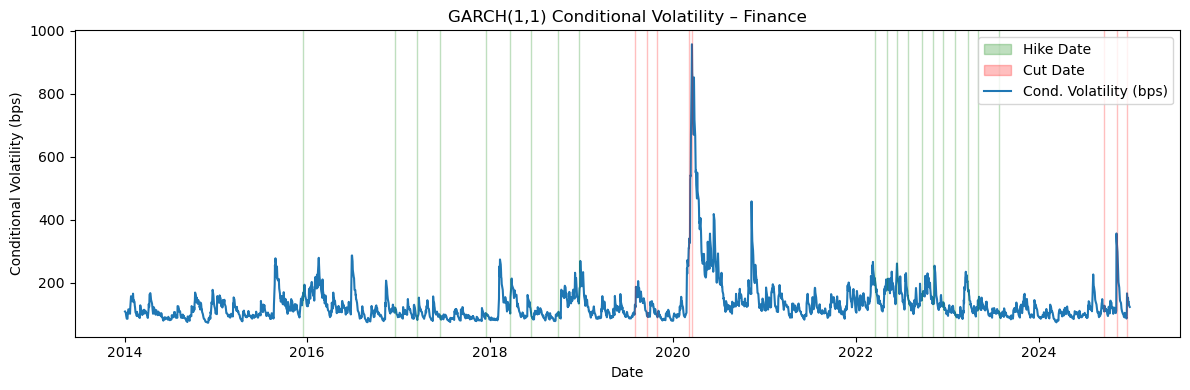

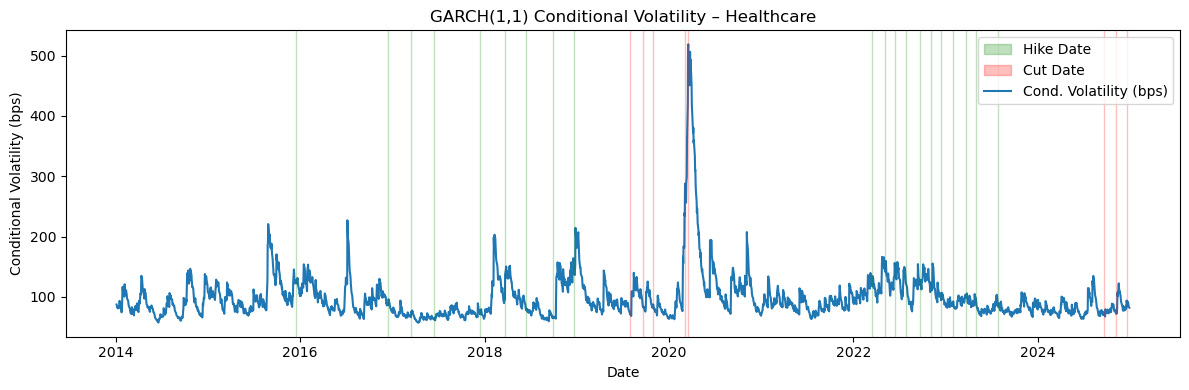

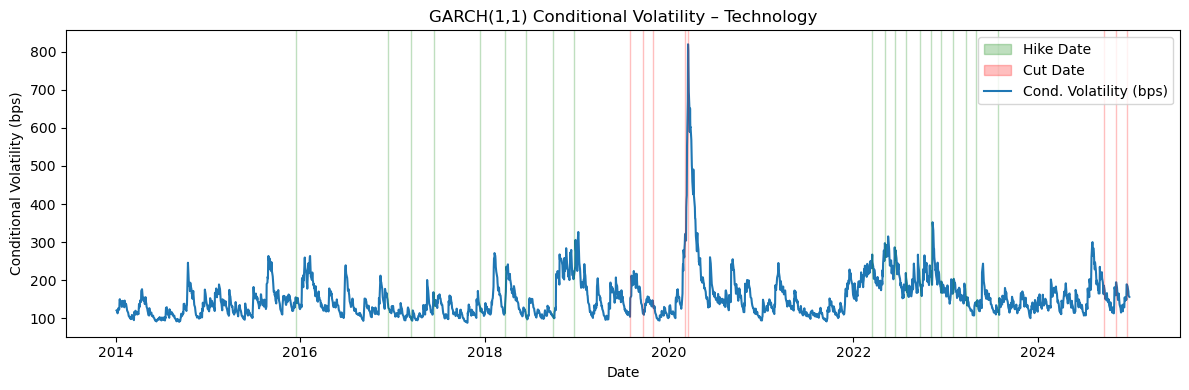

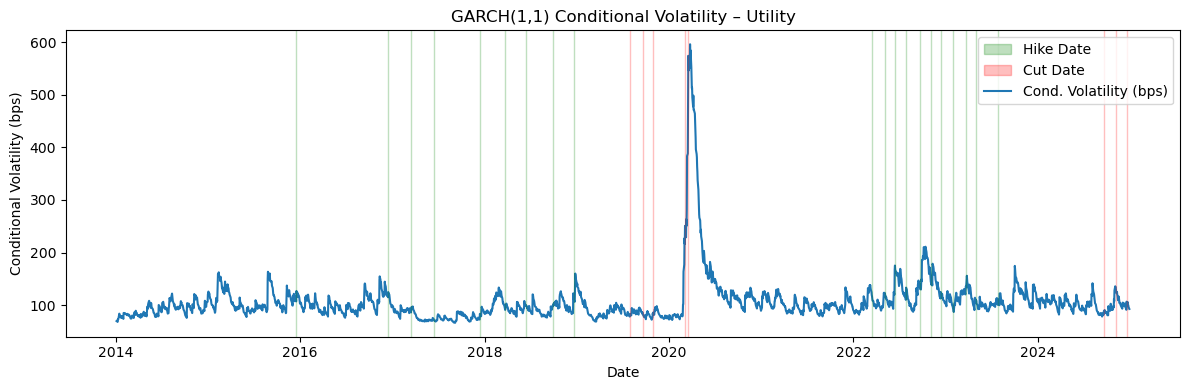

In [168]:
for sector, g in sector_ret.groupby('sector'):
    # drop only rows without returns
    g = g.dropna(subset=['ret'])
    if g.empty:
        continue

    y = g['ret'].astype(float) * 100
    X = g[['is_hike', 'is_cut']].astype(float)

    am = arch_model(
        y,
        x=X,
        mean='ARX',
        lags=0,
        vol='GARCH',
        p=1, q=1,
        dist='normal'
    )
    res = am.fit(update_freq=20, disp='off')

    g = g.copy()
    g['cond_vol_pct'] = res.conditional_volatility
    g['cond_vol_bps'] = g['cond_vol_pct'] * 100

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(g['Date'], g['cond_vol_bps'], label='Cond. Volatility (bps)')
        # Add FOMC vertical lines: green=hike, red=cut
    start, end = g['Date'].min(), g['Date'].max()
    for _, ev in events_plot.iterrows():
        dt = ev['Date']
        if dt < start or dt > end:
            continue
        color = 'green' if ev['event_type'] == 'hike' else 'red'
        ax.axvline(dt, color=color, alpha=0.25, linewidth=1)

    # Legend entries for hikes/cuts
    legend_handles = [
        Patch(color='green', alpha=0.25, label='Hike Date'),
        Patch(color='red',   alpha=0.25, label='Cut Date')
    ]

    ax.set_title(f"GARCH(1,1) Conditional Volatility – {sector}")
    ax.set_ylabel("Conditional Volatility (bps)")
    ax.set_xlabel("Date")
    ax.legend(handles=legend_handles + [ax.lines[0]], loc='upper right')

    plt.tight_layout()
    plt.show()


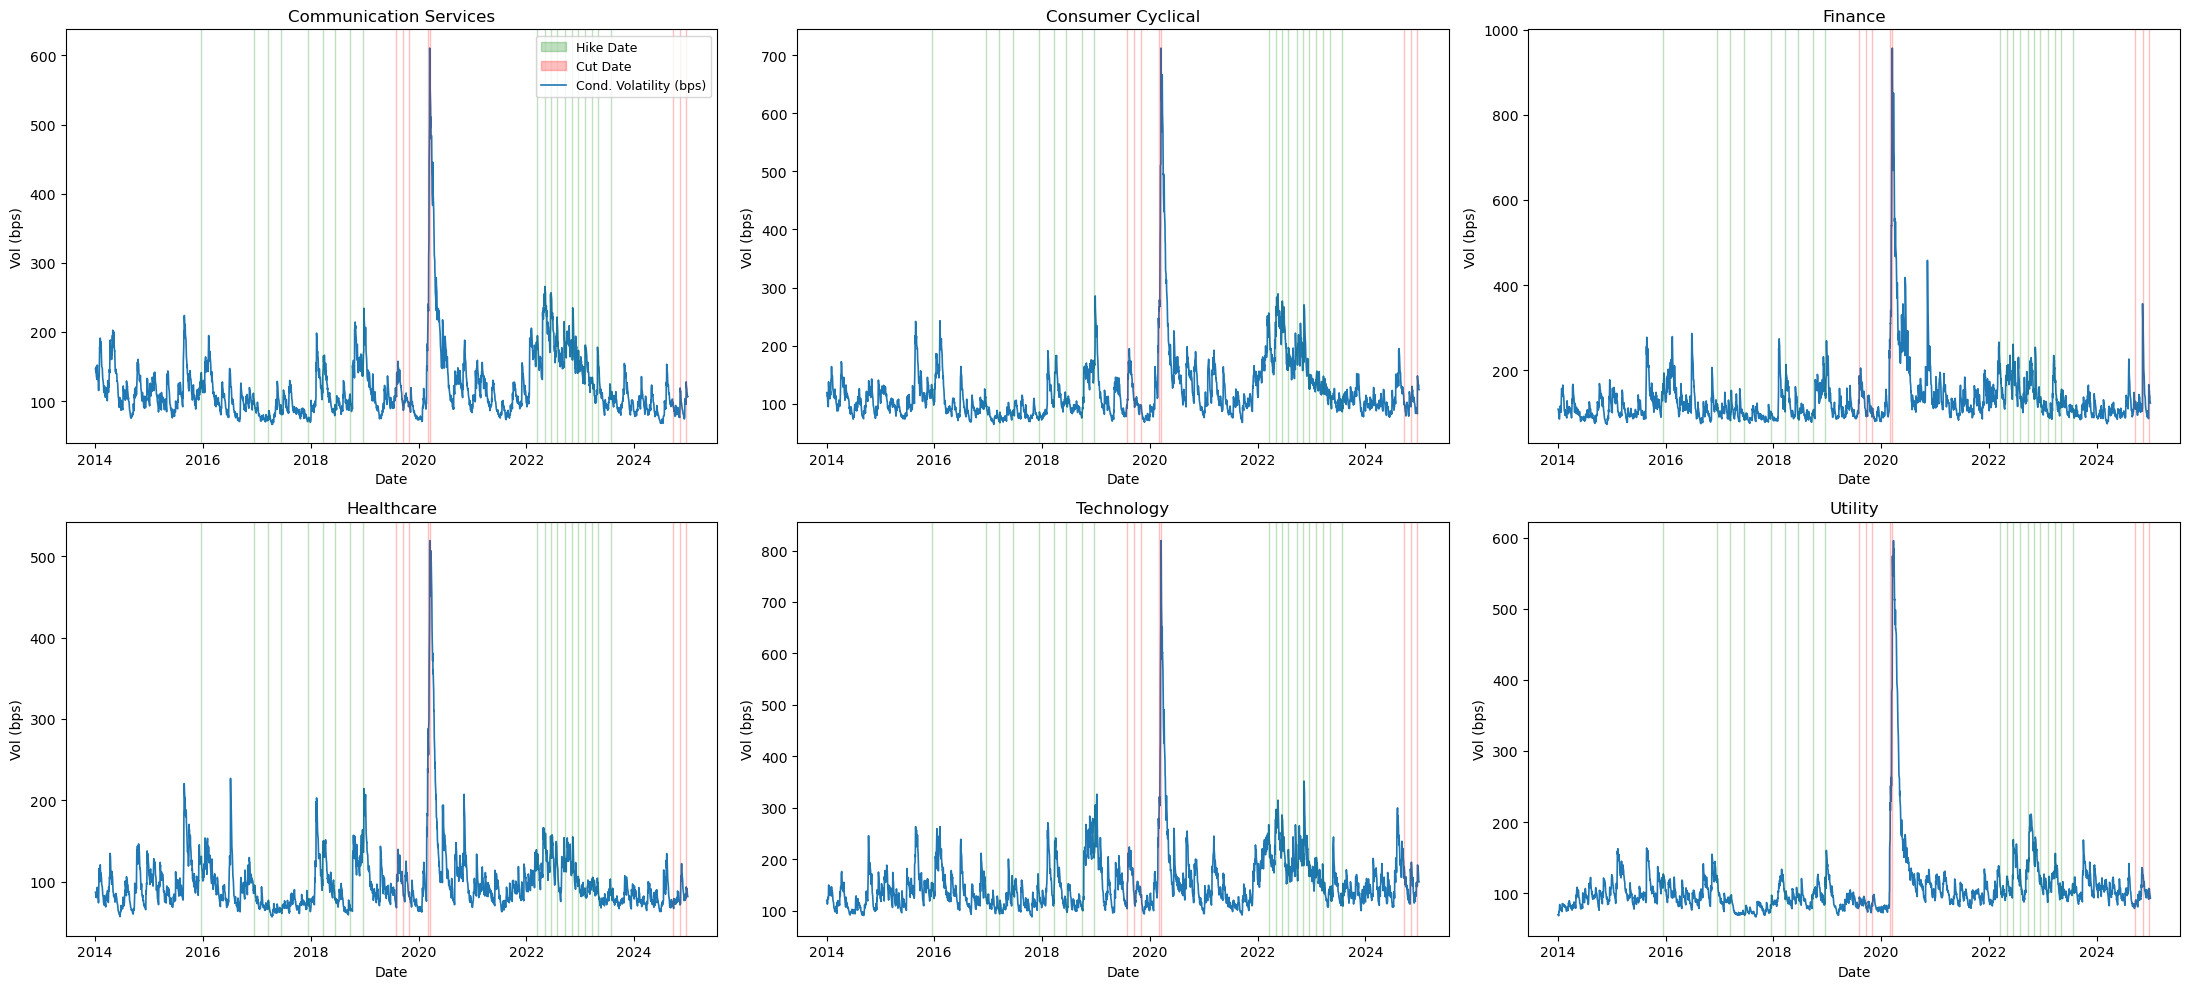

In [169]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from arch import arch_model

# Identify unique sectors
unique_sectors = sector_ret['sector'].dropna().unique()

fig, axes = plt.subplots(2, 3, figsize=(22, 10), sharex=False)
axes = axes.flatten()

legend_handles = [
    Patch(color='green', alpha=0.25, label='Hike Date'),
    Patch(color='red',   alpha=0.25, label='Cut Date')
]

for i, sector in enumerate(unique_sectors):
    if i >= 6:
        break  # Only plot first 6 sectors for a 2×3 grid

    ax = axes[i]

    # Filter and clean data
    g = sector_ret[sector_ret['sector'] == sector].dropna(subset=['ret'])
    if g.empty:
        ax.set_visible(False)
        continue

    y = g['ret'].astype(float) * 100
    X = g[['is_hike', 'is_cut']].astype(float)

    # Fit GARCH(1,1)
    am = arch_model(y, x=X, mean='ARX', lags=0,
                    vol='GARCH', p=1, q=1, dist='normal')
    res = am.fit(update_freq=20, disp='off')

    # Save conditional volatility
    g = g.copy()
    g['cond_vol_pct'] = res.conditional_volatility
    g['cond_vol_bps'] = g['cond_vol_pct'] * 100

    # Plot conditional volatility
    ax.plot(g['Date'], g['cond_vol_bps'], label='Cond. Volatility (bps)', linewidth=1.2)

    # Add event vertical lines
    start, end = g['Date'].min(), g['Date'].max()
    for _, ev in events_plot.iterrows():
        dt = ev['Date']
        if start <= dt <= end:
            color = 'green' if ev['event_type'] == 'hike' else 'red'
            ax.axvline(dt, color=color, alpha=0.25, linewidth=1)

    # Titles / labels
    ax.set_title(f"{sector}", fontsize=12)
    ax.set_ylabel("Vol (bps)")
    ax.set_xlabel("Date")

    # Add legend inside grid only once
    if i == 0:
        ax.legend(handles=legend_handles + [ax.lines[0]],
                  loc='upper right', fontsize=9)

# Turn off unused subplots (if < 6 sectors)
for j in range(i+1, 6):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


FOMC avg vol: 1.5672439265612694
Other avg vol: 0.8029373795267091


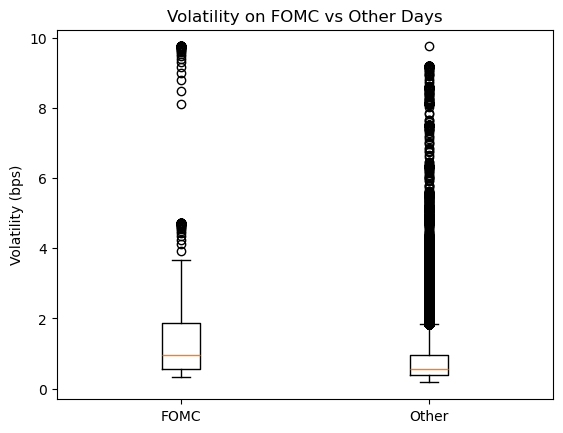

In [170]:
import numpy as np

fomc_vol = garch_df.loc[garch_df['is_hike'] + garch_df['is_cut'] > 0, 'cond_vol_bps']
other_vol = garch_df.loc[garch_df['is_hike'] + garch_df['is_cut'] == 0, 'cond_vol_bps']

print("FOMC avg vol:", fomc_vol.mean())
print("Other avg vol:", other_vol.mean())
plt.boxplot([fomc_vol, other_vol], labels=['FOMC', 'Other'])
plt.ylabel("Volatility (bps)")
plt.title("Volatility on FOMC vs Other Days")
plt.show()


**Model 5 Panel OLS**: PanelOLS with entity fixed effects measures how FOMC shocks change returns for the same stock over time, while OLS averages across stocks and cannot control for permanent differences between them.
$$
r_{i,t}
= \alpha_i
+ \delta_t
+ \beta_1 \,\text{is\_hike}_t
+ \beta_2 \,\text{is\_cut}_t
+ \beta_3 \,\Delta\text{rate}_t
+ u_{i,t}.
$$


In [171]:
from linearmodels.panel import PanelOLS
import pandas as pd

df = final_df.copy()

# ensure sorted
df = df.sort_values(['ticker', 'Date'])

# set panel index
df = df.set_index(['ticker', 'Date'])

mod = PanelOLS(
    df['ret'],
    df[['is_hike', 'is_cut', 'change_bps']],
    entity_effects=True   # stock FE
)

res = mod.fit(cov_type='clustered', cluster_entity=True)
print(res)


                          PanelOLS Estimation Summary                           
Dep. Variable:                    ret   R-squared:                        0.0692
Estimator:                   PanelOLS   R-squared (Between):            1.11e-16
No. Observations:                1680   R-squared (Within):               0.0692
Date:                Fri, Dec 12 2025   R-squared (Overall):              0.0679
Time:                        10:39:46   Log-likelihood                    3342.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      60.154
Entities:                          60   P-value                           0.0000
Avg Obs:                       28.000   Distribution:                  F(2,1618)
Min Obs:                       28.000                                           
Max Obs:                       28.000   F-statistic (robust):             117.80
                            

/opt/anaconda3/lib/python3.12/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


- A rate hike day is associated with an average abnormal return of −2.09% for individual stocks, after controlling for all stock-specific characteristics.
- A rate cut day is associated with an average abnormal return of +0.73%.
- Each additional 1 bp increase in the policy rate is associated with +0.04% in stock returns.